# AERO 355 - HW2
*Created by Henry Flushman*

---

### Imports

In [191]:
import math
import numpy as np
import matplotlib.pyplot as plt
import os

---
# Interplanetary MM Background Flux
---
### Question 2
**Solving and Plotting for Micrometeroid Background Flux at 1AU**

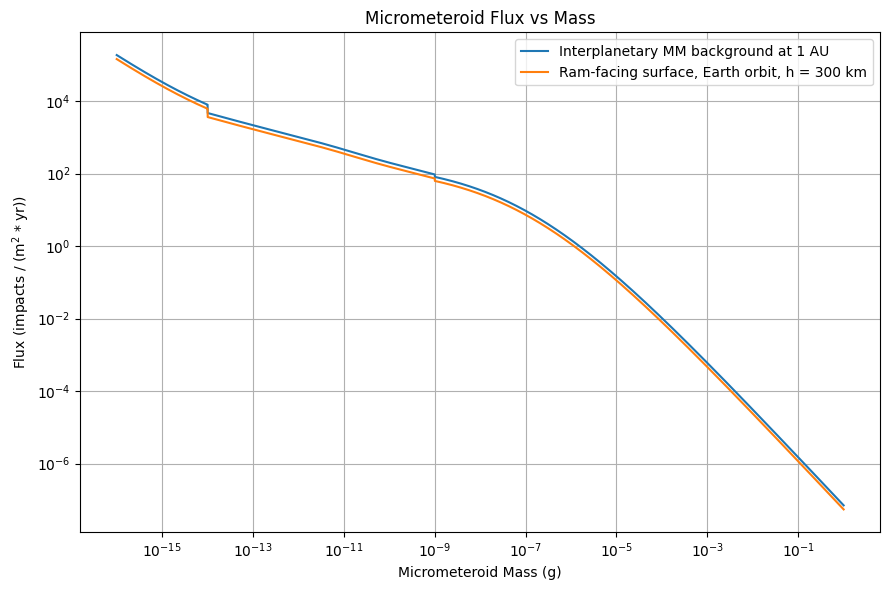

In [192]:
# --- Masses ---------
mm1 = np.linspace(10**-16, 10**-13, 1_000_000)
mm2 = np.linspace(10**-13, 10**-10, 1_000_000)
mm3 = np.linspace(10**-10, 10**-6,  1_000_000)
mm4 = np.linspace(10**-6,  10**-3,  1_000_000)
mm5 = np.linspace(10**-3,  1,       1_000_000)

mm = np.concatenate((mm1, mm2, mm3, mm4, mm5))
mm = np.unique(mm)

def BackgroundFlux(m):
    """
    Background micrometeroid flux at 1 AU
    
    var:
        m - mass in grams
        
    returns:
        Background Flux
    """
    A = (15 + 2.2e3 * m**0.306)**(-4.38)
    B = 1.3e-9 * (m + 1e11 * m**2 + 1e27 * m**4)**(-0.36)
    C = 1.3e-16 * (m + 1e6 * m**2)**(-0.85)
    
    F = np.zeros_like(m)
    
    # For 10^-18 g < m < 10^-14 g --> A + B + C
    mask_C = m < 1e-14
    F[mask_C] = 3.15576e7 * (A[mask_C] + B[mask_C] + C[mask_C])
    
    # For 10^-14 g <= m < 10^-9 g --> A + B
    mask_B = (m >= 1e-14) & (m < 1e-9)
    F[mask_B] = 3.15576e7 * (A[mask_B] + B[mask_B])
    
    # For 10^-9 g <= m <= 1 g --> A
    mask_A = m >= 1e-9
    F[mask_A] = 3.15576e7 * (A[mask_A])
    
    return F

# Sporadic Functions
def GravitationalFocus(h, Re=6378.0):
    """
    Gravitational Focus factor given a specific altitude in kilometers
    """
    return 1 + (Re+100)/(Re+h)
    
def EarthShieldingFactor(h, Re=6378.0):
    """
    Earth shielding factor given a specific altitude in kilometers
    """
    eta = np.arcsin((Re+100)/(Re+h))
    return (1+np.cos(eta))/2

def DistributionFactor(h, Re=6378.0):
    """
    The distribution factor given a specific altitude in kilometers
    """
    sqrtVal = 1 - ((Re+100)/(Re+h))**2
    return (1.8 + 3*np.sqrt(sqrtVal))/4

def FluxEarthOrbit(m, h):
    """
    Micrometeroid Flux on the ram-facing surface for an earth orbit
    vals:
        m - grams
        h - km
    """
    Fbg = BackgroundFlux(m)
    xi = EarthShieldingFactor(h)
    grav = GravitationalFocus(h)
    dist = DistributionFactor(h)
    return Fbg * xi * grav * dist

# --- Graphing ------------------------------
h = 300.0       # km
Flux_1AU = BackgroundFlux(mm)
Flux_orbit = FluxEarthOrbit(mm, h)

FullFactor_300 = (
    EarthShieldingFactor(h)*GravitationalFocus(h)*DistributionFactor(h)
)

plt.figure(figsize=(9,6))
plt.loglog(mm, Flux_1AU, label='Interplanetary MM background at 1 AU')
plt.loglog(mm, Flux_orbit, label='Ram-facing surface, Earth orbit, h = 300 km')

plt.xlabel('Micrometeroid Mass (g)')
plt.ylabel('Flux (impacts / (m$^2$ * yr))')
plt.title('Micrometeroid Flux vs Mass')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

---
### Question 4
**Total Reduction/Addition Factor**

In [193]:
print(f"Earth shielding factor at 300 km: {EarthShieldingFactor(h):.4f}")
print(f"Gravitational focus at 300 km:    {GravitationalFocus(h):.4f}")
print(f"Distribution factor at 300 km:    {DistributionFactor(h):.4f}")
print(f"Overall multiplier at 300 km:     {FullFactor_300:.4f}")

Earth shielding factor at 300 km: 0.6215
Gravitational focus at 300 km:    1.9701
Distribution factor at 300 km:    0.6322
Overall multiplier at 300 km:     0.7740


---
### Question 5
**Specific flux value for MM mass 10^-6g and greater**

In [194]:
print(f"The specific flux value for MM mass greater than or equal to 10^-6 is: \n{FullFactor_300*BackgroundFlux(np.array([1e-6]))[0]:.3f} impacts per (m^2 - year)")

The specific flux value for MM mass greater than or equal to 10^-6 is: 
1.149 impacts per (m^2 - year)


---
# Human-Made Orbital Debris Flux
---
### Question 6
**Solving and Plotting for Orbital Debris Flux**

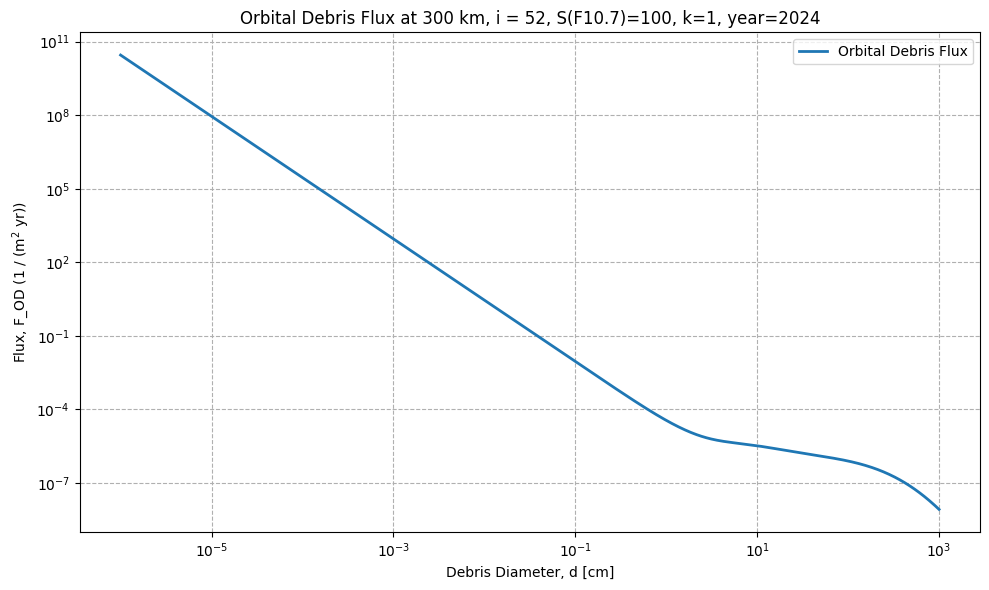

In [195]:
# --- Inputs --------------
z = 300.0       # km
inc = 52.0      # degrees
S = 100.0       # F10.7
k = 1.0
t = 2024.0

# Diameter range
d = np.logspace(-6, 3, 1000)    # cm

psi_table = {
    25: 0.900, 26: 0.905, 27: 0.910, 28: 0.912, 28.5: 0.9135,
    29: 0.915, 30: 0.920, 31: 0.922, 32: 0.927, 33: 0.930,
    34: 0.935, 35: 0.940, 36: 0.945, 37: 0.950, 38: 0.952,
    39: 0.957, 40: 0.960, 41: 0.967, 42: 0.972, 43: 0.977,
    44: 0.982, 45: 0.990, 46: 0.995, 47: 1.000, 48: 1.005,
    49: 1.010, 50: 1.020, 51: 1.025, 52: 1.030, 53: 1.040,
    54: 1.045, 55: 1.050, 56: 1.060, 57: 1.065, 58: 1.075,
    59: 1.080, 60: 1.090, 61: 1.100, 62: 1.115, 63: 1.130,
    64: 1.140, 65: 1.160, 66: 1.180, 67: 1.200, 68: 1.220,
    69: 1.240, 70: 1.260, 71: 1.290, 72: 1.310, 73: 1.340,
    74: 1.380, 75: 1.410, 76: 1.500, 77: 1.630, 78: 1.680,
    79: 1.700, 80: 1.710, 81: 1.700, 82: 1.680, 83: 1.610,
    84: 1.530, 85: 1.490, 86: 1.450, 87: 1.410, 88: 1.390,
    89: 1.380, 90: 1.370, 91: 1.380, 92: 1.400, 93: 1.440,
    94: 1.500, 95: 1.550, 96: 1.640, 97: 1.700, 98: 1.750,
    99: 1.770, 100: 1.780, 101: 1.770, 102: 1.750, 103: 1.720,
    104: 1.690, 105: 1.660, 106: 1.610, 107: 1.560, 108: 1.510,
    109: 1.460, 110: 1.410, 111: 1.380, 112: 1.350, 113: 1.320,
    114: 1.300, 115: 1.280, 116: 1.260, 117: 1.240, 118: 1.220,
    119: 1.200, 120: 1.180, 121: 1.165, 122: 1.155, 123: 1.140,
    124: 1.125, 125: 1.110
}


def psi_inc(inc):
    """
    Inclination factor
    Uses table to lookup, interpolates for values not found on table
    """
    keys = np.array(sorted(psi_table.keys()), dtype=float)
    vals = np.array([psi_table[k] for k in keys], dtype=float)
    return np.interp(inc, keys, vals)

# Functions for describing debris model
def H_d(d):
    return (10.0 ** np.exp(-((np.log10(d) - 0.78) / 0.637)**2))**(1/3)

def Phi_zS(z, S):
    phi1 = 10.0 ** (z/100.0 - S/140.0 - 1.5)
    return phi1 / (phi1 + 1.0)

def F1_d(d):
    return 1.22e-5 * d ** (-2.5)

def F2_d(d):
    return 8.1e10 * (d+700) ** (-6.0)

def g1_t(year):
    q = 0.02
    qPrime = 0.04
    
    if year < 2011:
        return (1.0+q) ** (year-1988.0)
    else:
        return ((1.0+q) ** 23.0) * ((1.0+qPrime) ** (year-2011.0))
    
def g2_t(year):
    p = 0.05
    return 1.0 + p * (year - 1988.0)

def OrbitalDebrisFlux(d, z, inc, S, k, year):
    """
    Full orbital debris flux model
    F = k * H(d) * phi(z, S) * psi(i) * [F1(d)g1(t) + F2(d)g2(t)]
    """
    H = H_d(d)
    phiVal = Phi_zS(z, S)
    psiVal = psi_inc(inc)
    F1, F2 = F1_d(d), F2_d(d)
    g1, g2 = g1_t(year), g2_t(year)
    
    return k * H * phiVal * psiVal * (F1*g1 + F2*g2)


# --- Flux Plot and Analysis ----------------------------

FluxOD = OrbitalDebrisFlux(d, z, inc, S, k, t)

plt.figure(figsize=(10, 6))
plt.loglog(d, FluxOD, linewidth=2, label='Orbital Debris Flux')

plt.xlabel('Debris Diameter, d [cm]')
plt.ylabel('Flux, F_OD (1 / (m$^2$ yr))')
plt.title('Orbital Debris Flux at 300 km, i = 52, S(F10.7)=100, k=1, year=2024')
plt.grid(True, which='both', linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

---
### Question 8
**Specific flux for 10^-3 cm and greater**

In [196]:
d_target = 1e-3     # cm

idx = np.argmin(np.abs(d-d_target))
fluxVal = FluxOD[idx]

print(f"Flux for d >= 1e-3 cm: {fluxVal:.3f} 1/(m^2*yr)")

Flux for d >= 1e-3 cm: 896.520 1/(m^2*yr)


---
### Question 9
**Specific flux for 10^-3 cm and greater for 2030**

In [197]:
FluxOD_2030 = OrbitalDebrisFlux(d, z, inc, S, k, 2030.0)

d_target_2030 = 1e-3
d_2030 = np.logspace(-6, 3, 1000)

idx_2030 = np.argmin(np.abs(d-d_target_2030))
fluxVal_2030 = FluxOD_2030[idx_2030]

print(f"Flux for d >= 1e-3 cm in 2030: {fluxVal_2030:.3f}")

Flux for d >= 1e-3 cm in 2030: 1134.384


---
# Crater Diameter Calculations
---
### Question 10
**Crater diameter for an aluminum target**


In [206]:
def CraterDiameter(K, d, rhoP, v):
    return K * d**(1.056) * rhoP**(0.579) * v**(2/3)

print(f"{CraterDiameter(0.351, 1.0, 3.5, 10.0):.2f} cm")

3.37 cm


---
### Question 11
**Specific Number for Shield Thickness**

In [214]:
def CriticalThickness(K, rhoP, m, v):
    return K * rhoP**(1/6) * m**(0.352) * v**(0.875)

print(f"{CriticalThickness(0.351, 3.5, 1, 10):.2f} cm")

3.24 cm


---
# Finding Impact Diameter Given Previous Flux
---
### Question 12
**Part a: Calculating PNCF**

In [ ]:
dCrit = 0.8             # cm
A = 735.0               # m^2
T = 1.0                 # year

fluxCrit = OrbitalDebrisFlux(np.array([dCrit]), z, inc, S, k, 2024.0)[0]

N_critical = fluxCrit * A * T

PNCF_penetration = np.exp(-N_critical)

print(f"PNCF over 1 year: {PNCF_penetration:.4f}")

5.748398425728803e-05
PNCF over 1 year: 0.9586


---
### Question 13
**Part b: PNP for TPS over 1 year**

In [234]:
dPenetration = 0.3      # cm
A = 735.0               # m^2
T = 1.0                 # year

fluxPen = OrbitalDebrisFlux(np.array([dPenetration]), z, inc, S, k, 2024.0)[0]
N_penetration = fluxPen * A * T
PNP = 1 - np.exp(-N_penetration)

print(f"PNP over 1 year: {PNP:.4f}")

PNP over 1 year: 0.3488
